# plot the eta car light curve]

- [load data](#load-data)

- [convert to AB mag](#convert-to-AB-magnitude)

- [estimate temperature](#estimate-temperature)

- [estimate radius](#estimate-radius)

- [compare with other transients](#compare-with-other-transients)

- [period analysis](#period-analysis)



In [1]:
from LC_utility import *

In [715]:
plt.rcParams['axes.labelsize'] = 18     # size of x/y labels
plt.rcParams['xtick.labelsize'] = 18    # size of tick labels
plt.rcParams['ytick.labelsize'] = 18

plt.rcParams['legend.fontsize'] = 18

In [698]:
plt.rcParams

RcParams({'_internal.classic_mode': False,
          'agg.path.chunksize': 0,
          'animation.bitrate': -1,
          'animation.codec': 'h264',
          'animation.convert_args': ['-layers', 'OptimizePlus'],
          'animation.convert_path': 'convert',
          'animation.embed_limit': 20.0,
          'animation.ffmpeg_args': [],
          'animation.ffmpeg_path': 'ffmpeg',
          'animation.frame_format': 'png',
          'animation.html': 'none',
          'animation.writer': 'ffmpeg',
          'axes.autolimit_mode': 'data',
          'axes.axisbelow': 'line',
          'axes.edgecolor': 'black',
          'axes.facecolor': 'white',
          'axes.formatter.limits': [-5, 6],
          'axes.formatter.min_exponent': 0,
          'axes.formatter.offset_threshold': 4,
          'axes.formatter.use_locale': False,
          'axes.formatter.use_mathtext': False,
          'axes.formatter.useoffset': True,
          'axes.grid': False,
          'axes.grid.axis': 'both',
   

## load data

In [3]:
### Read in Models
lcpath = './data/'
LCm2_i = pd.read_csv(lcpath +'M2_iEtaCarLC.csv')
LCm2_g = pd.read_csv(lcpath +'M2_gEtaCarLC.csv')
LCm2_r = pd.read_csv(lcpath +'M2_rEtaCarLC.csv')
LCm2_z = pd.read_csv(lcpath +'M2_zEtaCarLC.csv')

In [5]:
LCm2_i

,mjd,mJyas2,mJyas2_err
0,53438.236309,8.470009,0.196721
1,53551.757954,7.672807,0.201869
2,53709.322149,6.883488,0.303433
3,53760.297340,5.908279,0.249547
4,53827.987534,7.323063,0.263127
...,...,...,...
393,64042.016000,0.174614,0.262234
394,64230.472709,0.785830,0.452681
395,64510.089645,1.102539,0.148120
396,64648.439366,0.236227,0.250838


<ErrorbarContainer object of 3 artists>

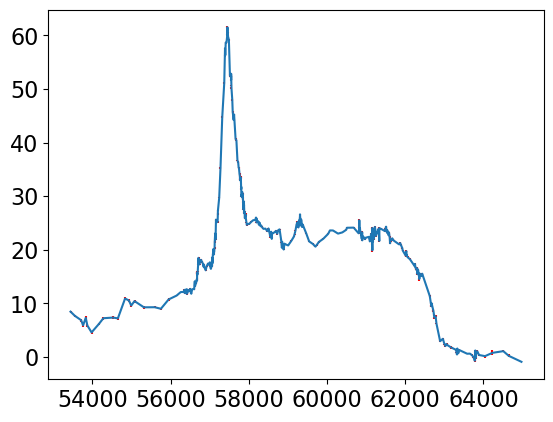

In [7]:

x = LCm2_i['mjd']
y = LCm2_i['mJyas2']
y_err = LCm2_i['mJyas2_err']
plt.errorbar(x, y, y_err, ecolor='r')




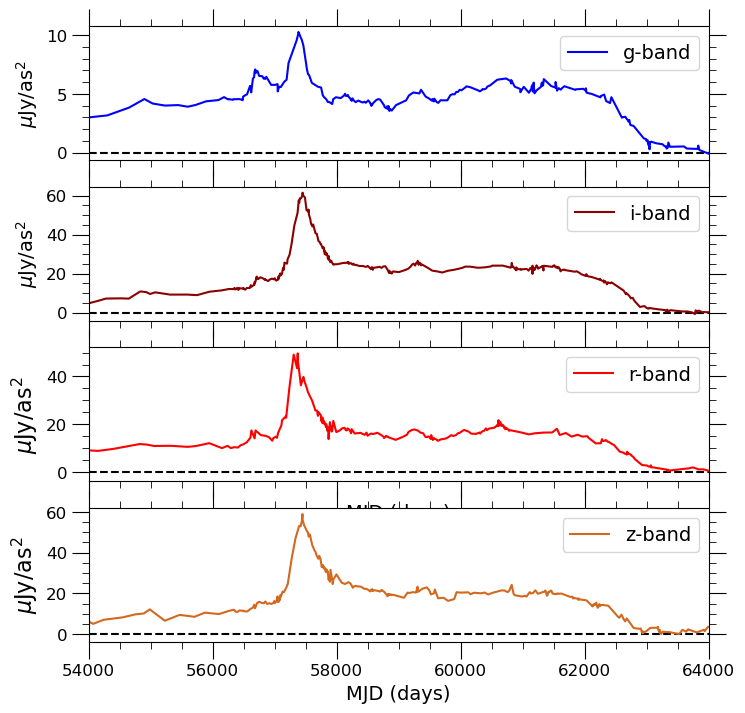

In [8]:
fig, axs = plt.subplots(4,1,dpi = 100, figsize = [8,8], sharex=True)
axs = axs.flatten() 

axs[0].minorticks_on()
axs[0].tick_params(axis='x', labelsize=12)
axs[0].tick_params(axis='y', labelsize=12)
axs[0].tick_params(which='major',bottom='on',top='on',left='on',right='on',length=12)
axs[0].tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=5)
# axs[0].gca().set_xlabel('mjd', fontsize = 14)
axs[0].set_ylabel(r'$\mu$Jy/as$^2$', fontsize = 14)
axs[0].ticklabel_format(axis='both', style='plain')

axs[0].errorbar(LCm2_g['mjd'], LCm2_g['mJyas2'], fmt='-', ecolor='black', color='blue', label='g-band')
axs[0].axhline(y=0, linestyle='--', color='black')
axs[0].set_xlim(54000, 64000)
axs[0].legend(fontsize = 14)


axs[1].minorticks_on()
axs[1].tick_params(axis='x', labelsize=12)
axs[1].tick_params(axis='y', labelsize=12)
axs[1].tick_params(which='major',bottom='on',top='on',left='on',right='on',length=12)
axs[1].tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=5)
axs[1].set_ylabel(r'$\mu$Jy/as$^2$', fontsize = 14)
axs[1].ticklabel_format(axis='both', style='plain')

axs[1].errorbar(LCm2_i['mjd'], LCm2_i['mJyas2'], fmt='-', ecolor='black', color='darkred', label='i-band')
axs[1].axhline(y=0, linestyle='--', color='black')
axs[1].set_xlim(54000, 64000)
axs[1].legend(fontsize = 14)


axs[2].minorticks_on()
axs[2].tick_params(axis='x', labelsize=12)
axs[2].tick_params(axis='y', labelsize=12)
axs[2].tick_params(which='major',bottom='on',top='on',left='on',right='on',length=12)
axs[2].tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=5)
axs[2].set_xlabel('MJD (days)', fontsize = 14)
axs[2].set_ylabel(r'$\mu$Jy/as$^2$', fontsize = 16)
axs[2].ticklabel_format(axis='both', style='plain')

axs[2].errorbar(LCm2_r['mjd'], LCm2_r['mJyas2'], fmt='-', ecolor='black', color='red', label='r-band')
axs[2].axhline(y=0, linestyle='--', color='black')
axs[2].set_xlim(54000, 64000)
axs[2].legend(fontsize = 14)


axs[3].minorticks_on()
axs[3].tick_params(axis='x', labelsize=12)
axs[3].tick_params(axis='y', labelsize=12)
axs[3].tick_params(which='major',bottom='on',top='on',left='on',right='on',length=12)
axs[3].tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=5)
axs[3].set_xlabel('MJD (days)', fontsize = 14)
axs[3].set_ylabel(r'$\mu$Jy/as$^2$', fontsize = 16)
axs[3].ticklabel_format(axis='both', style='plain')

axs[3].errorbar(LCm2_z['mjd'], LCm2_z['mJyas2'], fmt='-', ecolor='black', color='chocolate', label='z-band')
axs[3].axhline(y=0, linestyle='--', color='black')
axs[3].set_xlim(54000, 64000)
axs[3].legend(fontsize = 14)

## convert to AB magnitude

In [9]:
working_inds_i = np.where(LCm2_i['mJyas2']>0.)[0]
working_inds_g = np.where(LCm2_g['mJyas2']>0.)[0]
working_inds_r = np.where(LCm2_r['mJyas2']>0.)[0]
working_inds_z = np.where(LCm2_z['mJyas2']>0.)[0]

mag_i, mag_err_i = convert_Jy2mag(LCm2_i.loc[working_inds_i,'mJyas2'].values, LCm2_i.loc[working_inds_i,'mJyas2_err'].values)
mag_g, mag_err_g = convert_Jy2mag(LCm2_g.loc[working_inds_g,'mJyas2'].values, LCm2_g.loc[working_inds_g,'mJyas2_err'].values)
mag_r, mag_err_r = convert_Jy2mag(LCm2_r.loc[working_inds_r,'mJyas2'].values, LCm2_r.loc[working_inds_r,'mJyas2_err'].values)
mag_z, mag_err_z = convert_Jy2mag(LCm2_z.loc[working_inds_z,'mJyas2'].values, LCm2_z.loc[working_inds_z,'mJyas2_err'].values)

LCm2_i.loc[working_inds_i,'AB_mag'] = np.array(mag_i)
LCm2_i.loc[working_inds_i,'AB_mag_err'] = np.array(mag_err_i)
LCm2_g.loc[working_inds_g,'AB_mag'] = np.array(mag_g)
LCm2_g.loc[working_inds_g,'AB_mag_err'] = np.array(mag_err_g)
LCm2_r.loc[working_inds_r,'AB_mag'] = np.array(mag_r)
LCm2_r.loc[working_inds_r,'AB_mag_err'] = np.array(mag_err_r)
LCm2_z.loc[working_inds_z,'AB_mag'] = np.array(mag_z)
LCm2_z.loc[working_inds_z,'AB_mag_err'] = np.array(mag_err_z)

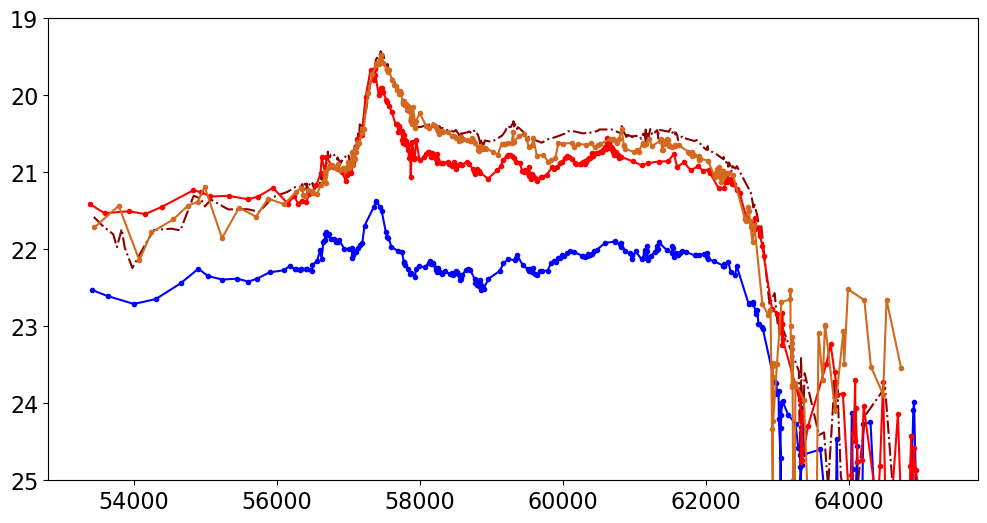

In [10]:
plt.subplots(dpi = 100, figsize = [12,6])
plt.errorbar(LCm2_g.loc[working_inds_g,'mjd'], LCm2_g.loc[working_inds_g,'AB_mag'], fmt='.-', ecolor='black', color='blue')
plt.errorbar(LCm2_i.loc[working_inds_i,'mjd'], LCm2_i.loc[working_inds_i,'AB_mag'], fmt='-.', ecolor='black', color='darkred')
plt.errorbar(LCm2_r.loc[working_inds_r,'mjd'], LCm2_r.loc[working_inds_r,'AB_mag'], fmt='.-', ecolor='black', color='red')
plt.errorbar(LCm2_z.loc[working_inds_z,'mjd'], LCm2_z.loc[working_inds_z,'AB_mag'], fmt='.-', ecolor='black', color='chocolate')


plt.ylim(19,25)
plt.gca().invert_yaxis()

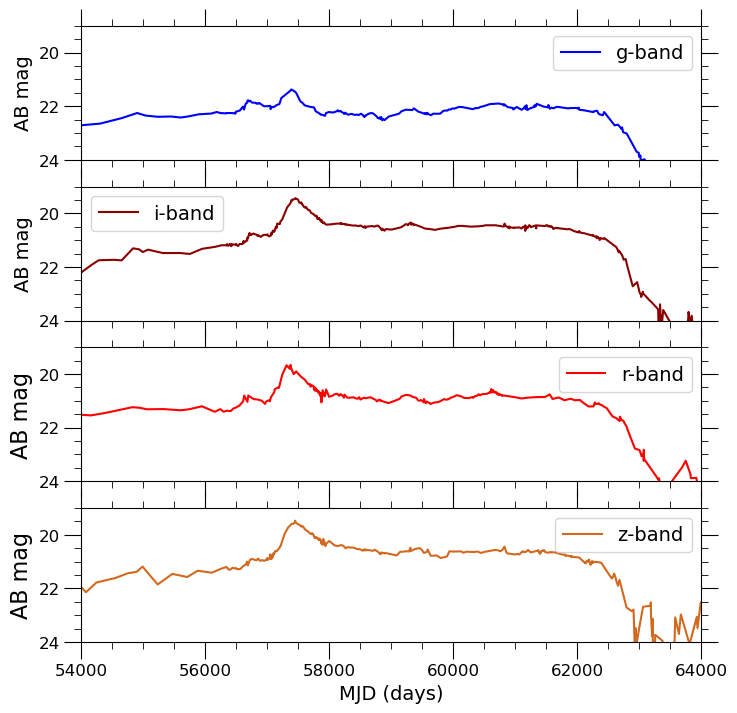

In [11]:
fig, axs = plt.subplots(4,1,dpi = 100, figsize = [8,8], sharex=True)
axs = axs.flatten() 

axs[0].minorticks_on()
axs[0].tick_params(axis='x', labelsize=12)
axs[0].tick_params(axis='y', labelsize=12)
axs[0].tick_params(which='major',bottom='on',top='on',left='on',right='on',length=12)
axs[0].tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=5)
# axs[0].gca().set_xlabel('mjd', fontsize = 14)
axs[0].set_ylabel('AB mag', fontsize = 14)
axs[0].ticklabel_format(axis='both', style='plain')

axs[0].errorbar(LCm2_g.loc[working_inds_g,'mjd'], LCm2_g.loc[working_inds_g,'AB_mag'], fmt='-', ecolor='black', color='blue', label='g-band')
axs[0].set_xlim(54000, 64000)
axs[0].set_ylim(19,24)
axs[0].invert_yaxis()
axs[0].legend(fontsize = 14)


axs[1].minorticks_on()
axs[1].tick_params(axis='x', labelsize=12)
axs[1].tick_params(axis='y', labelsize=12)
axs[1].tick_params(which='major',bottom='on',top='on',left='on',right='on',length=12)
axs[1].tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=5)
axs[1].set_ylabel('AB mag', fontsize = 14)
axs[1].ticklabel_format(axis='both', style='plain')

axs[1].errorbar(LCm2_i.loc[working_inds_i,'mjd'], LCm2_i.loc[working_inds_i,'AB_mag'], fmt='-', ecolor='black', color='darkred', label='i-band')
axs[1].set_xlim(54000, 64000)
axs[1].set_ylim(19,24)
axs[1].invert_yaxis()
axs[1].legend(fontsize = 14)


axs[2].minorticks_on()
axs[2].tick_params(axis='x', labelsize=12)
axs[2].tick_params(axis='y', labelsize=12)
axs[2].tick_params(which='major',bottom='on',top='on',left='on',right='on',length=12)
axs[2].tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=5)
axs[2].set_ylabel('AB mag', fontsize = 16)
axs[2].ticklabel_format(axis='both', style='plain')

axs[2].errorbar(LCm2_r.loc[working_inds_r,'mjd'], LCm2_r.loc[working_inds_r,'AB_mag'], fmt='-', ecolor='black', color='red', label='r-band')
axs[2].set_xlim(54000, 64000)
axs[2].set_ylim(19,24)
axs[2].invert_yaxis()
axs[2].legend(fontsize = 14)


axs[3].minorticks_on()
axs[3].tick_params(axis='x', labelsize=12)
axs[3].tick_params(axis='y', labelsize=12)
axs[3].tick_params(which='major',bottom='on',top='on',left='on',right='on',length=12)
axs[3].tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=5)
axs[3].set_xlabel('MJD (days)', fontsize = 14)
axs[3].set_ylabel('AB mag', fontsize = 16)
axs[3].ticklabel_format(axis='both', style='plain')

axs[3].errorbar(LCm2_z.loc[working_inds_z,'mjd'], LCm2_z.loc[working_inds_z,'AB_mag'], fmt='-', ecolor='black', color='chocolate', label='z-band')
axs[3].set_xlim(54000, 64000)
axs[3].set_ylim(19,24)
axs[3].invert_yaxis()
axs[3].legend(fontsize = 14)

In [13]:
t_ran = np.arange(54000, 63500)

i_new = splev(t_ran, splrep(LCm2_i.loc[working_inds_i,'mjd'], LCm2_i.loc[working_inds_i,'AB_mag'], k=1))
# i_new_err = splev(t_ran, splrep(LCm2_i.loc[working_inds_i,'mjd'], LCm2_i.loc[working_inds_i,'AB_mag_err'], k=1))
g_new = splev(t_ran, splrep(LCm2_g.loc[working_inds_g,'mjd'], LCm2_g.loc[working_inds_g,'AB_mag'], k=1))
# g_new_err = splev(t_ran, splrep(LCm2_g.loc[working_inds_g,'mjd'], LCm2_g.loc[working_inds_g,'AB_mag_err'], k=1))

r_new = splev(t_ran, splrep(LCm2_r.loc[working_inds_r,'mjd'], LCm2_r.loc[working_inds_r,'AB_mag'], k=1))
z_new = splev(t_ran, splrep(LCm2_z.loc[working_inds_z,'mjd'], LCm2_z.loc[working_inds_z,'AB_mag'], k=1))

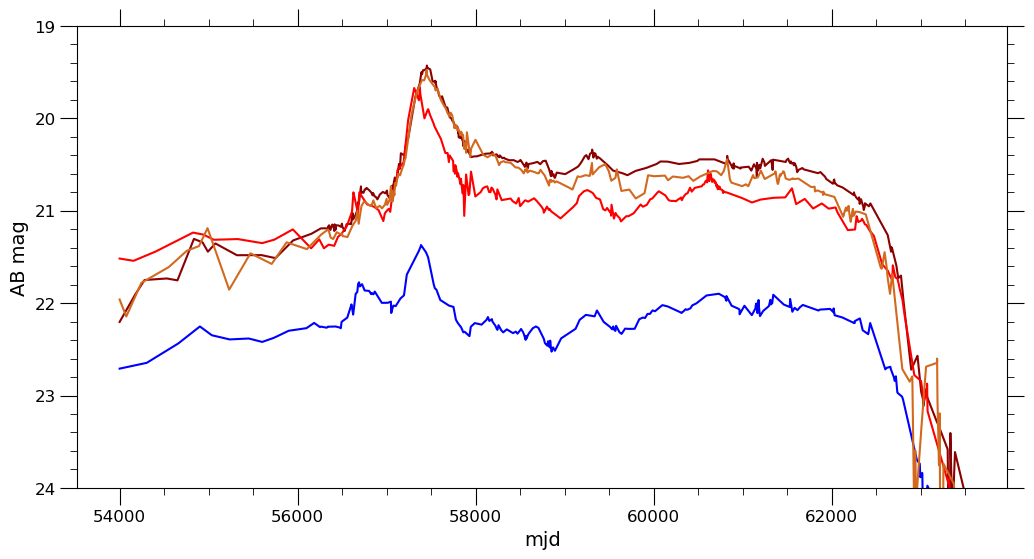

In [14]:
plt.subplots(dpi = 100, figsize = [12,6])
plt.minorticks_on()
plt.tick_params(axis='x', labelsize=12)
plt.tick_params(axis='y', labelsize=12)
plt.tick_params(which='major',bottom='on',top='on',left='on',right='on',length=12)
plt.tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=5)
plt.gca().set_xlabel('mjd', fontsize = 14)
plt.gca().set_ylabel('AB mag', fontsize = 14)
plt.ticklabel_format(axis='both', style='plain')

plt.errorbar(t_ran, g_new, ecolor='black', color='blue')
plt.errorbar(t_ran, i_new, ecolor='black', color='darkred')
plt.errorbar(t_ran, r_new, ecolor='black', color='red')
plt.errorbar(t_ran, z_new, ecolor='black', color='chocolate')

plt.ylim(19,24)
plt.gca().invert_yaxis()

# plt.axvline(54850, color='k', ls='--')
# plt.axvline(56740, color='k', ls='--')
# plt.axvline(57430, color='k', ls='--')
# plt.axvline(59300, color='k', ls='--')

## color plot

(0.0, 3.5)

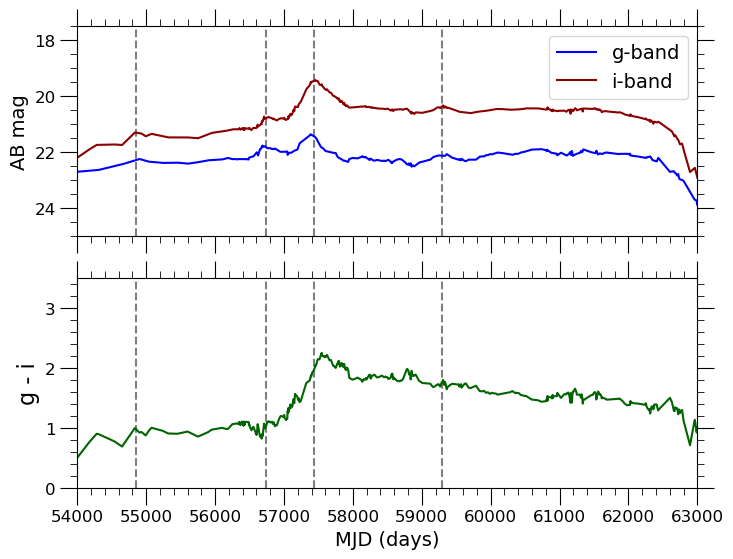

In [15]:
# g - i

fig, axs = plt.subplots(2,1,dpi = 100, figsize = [8,6], sharex=True)
axs = axs.flatten() 
axs[0].minorticks_on()
axs[0].tick_params(axis='x', labelsize=12)
axs[0].tick_params(axis='y', labelsize=12)
axs[0].tick_params(which='major',bottom='on',top='on',left='on',right='on',length=12)
axs[0].tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=5)
# axs[0].gca().set_xlabel('mjd', fontsize = 14)
axs[0].set_ylabel('AB mag', fontsize = 14)
axs[0].ticklabel_format(axis='both', style='plain')

axs[0].errorbar(t_ran, g_new, ecolor='black', color='blue',label='g-band')
axs[0].errorbar(t_ran, i_new, ecolor='black', color='darkred',label='i-band')

axs[0].axvline(54850, color='k', ls='--', alpha=0.5)
axs[0].axvline(56740, color='k', ls='--', alpha=0.5)
axs[0].axvline(57430, color='k', ls='--', alpha=0.5)
axs[0].axvline(59300, color='k', ls='--', alpha=0.5)
# axs[0].set_xlim(54000, 63000)
axs[0].set_ylim(17.5, 25)
axs[0].invert_yaxis()
axs[0].legend(fontsize = 14)

axs[1].minorticks_on()
axs[1].tick_params(axis='x', labelsize=12)
axs[1].tick_params(axis='y', labelsize=12)
axs[1].tick_params(which='major',bottom='on',top='on',left='on',right='on',length=12)
axs[1].tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=5)
axs[1].set_xlabel('MJD (days)', fontsize = 14)
axs[1].set_ylabel('g - i', fontsize = 16)
axs[1].ticklabel_format(axis='both', style='plain')

axs[1].errorbar(t_ran, g_new-i_new, ecolor='black', color='darkgreen')
axs[1].axvline(54850, color='k', ls='--', alpha=0.5)
axs[1].axvline(56740, color='k', ls='--', alpha=0.5)
axs[1].axvline(57430, color='k', ls='--', alpha=0.5)
axs[1].axvline(59300, color='k', ls='--', alpha=0.5)
axs[1].set_xlim(54000, 63000)
axs[1].set_ylim(0.0, 3.5)

# fig.savefig('../figures/display/EtaCar_ColorPlot.png', bbox_inches = 'tight', dpi = 100)


## estimate temperature

In [16]:
# data from A. Alonso et al.: Empirical calibration of Teff versus colours and [Fe/H].
t_effs = np.array([3500,3750,4000,4250,4500,4750,5000,5250,5500,5750,6000,6250,6500,6750,7000,7250,7500,7750,8000 ])

V_Is = np.array([2.800,2.210,1.865,1.625,1.435,1.275,1.135,1.015,0.910,0.815,0.725,0.645,0.575,0.505,0.440,0.380,0.325,0.275,0.225])


Theta = 5040 / t_effs



In [342]:
np.polyfit(V_Is, Theta, deg=3)

array([-0.0192951 ,  0.0197577 ,  0.41923694,  0.53356974])

In [17]:
t_effs = np.array([3750,  4000,  4250,  4500,  4750,  5000,  5250, 5500,  5750,  6000, 6250, 6500, 6750, 7000,  7250, 7500, 7750, 8000])

R_Is = np.array([1.005, 0.815, 0.690, 0.595, 0.520, 0.460, 0.405,0.360, 0.320, 0.285,0.255,0.225,0.2, 0.175, 0.155, 0.135, 0.120, 0.100])

Theta = 5040 / t_effs


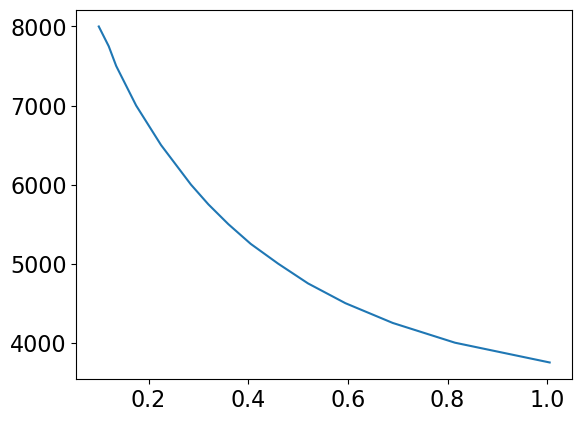

In [18]:
plt.plot(R_Is, t_effs)

In [19]:
np.polyfit(R_Is, np.log10(t_effs), deg=3)

array([-0.2610645 ,  0.78625533, -0.93975579,  3.98867204])

In [36]:
# V-I to T_eff

def vi_to_Teff(vi):
    """
    Convert (V-I) color to Teff [K] = 5040 / Theta.

    Theta = a0 + a1(V-I) + a2 (V-I)**2 + a3 (V-I)**3
    
    Reference: A. Alonso et al.: Empirical calibration of Teff versus colours and [Fe/H].
    """
    vi = np.asarray(vi)

    # value from np.polyfit
    a3, a2, a1, a0 = -0.0192951 ,  0.0197577 ,  0.41923694,  0.53356974
    
    Theta = a0 + a1 * vi + a2 * vi ** 2 + a3 * vi ** 3
    
    return 5040 / Theta

def gi_to_VI(gi):
    """
    Convert g-i to V-I, from
    https://www.sdss3.org/dr8/algorithms/sdssUBVRITransform.php#Jordi2006
    """
    VI = (0.675)*(gi)  + (0.364)
    return VI


In [37]:
def ri_to_RI(ri):
    """
    Convert g-i to V-I, from
    https://www.sdss3.org/dr8/algorithms/sdssUBVRITransform.php#Jordi2006
    """
    
    RI = (0.930)*ri + (0.259)

    return RI

def RI_to_Teff(RI):
    """
    """
    RI = np.asarray(RI)

    # value from np.polyfit
    #a3, a2, a1, a0 = -0.00372186, -0.48393689,  1.32916366,  0.50060817
    
    #Theta = a0 + a1 * RI + a2 * RI ** 2 + a3 * RI ** 3

    # return 5040 / T_eff

    a3, a2, a1, a0 = -0.2610645 ,  0.78625533, -0.93975579,  3.98867204

    logTeff = a0 + a1 * RI + a2 * RI ** 2 + a3 * RI ** 3
    
    return 10 ** logTeff


Text(0, 0.5, 'Teff')

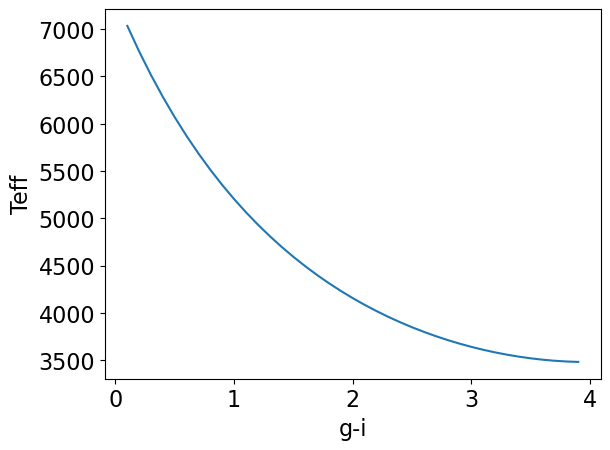

In [22]:
# the gi-Temperature relation

gi_s = np.arange(0.1, 4, .1)

vi_s = gi_to_VI(gi_s)

Teff_s = vi_to_Teff(vi_s)

plt.plot(gi_s, Teff_s)

plt.xlabel('g-i')
plt.ylabel('Teff')

Text(0, 0.5, 'Teff')

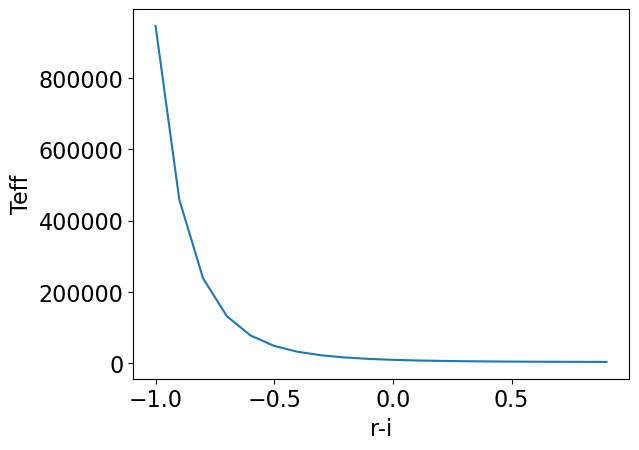

In [23]:
# the gi-Temperature relation

ri_s = np.arange(-1, 1, .1)

RI_s = ri_to_RI(ri_s)

Teff_s = RI_to_Teff(ri_s)

plt.plot(ri_s, Teff_s)

plt.xlabel('r-i')
plt.ylabel('Teff')

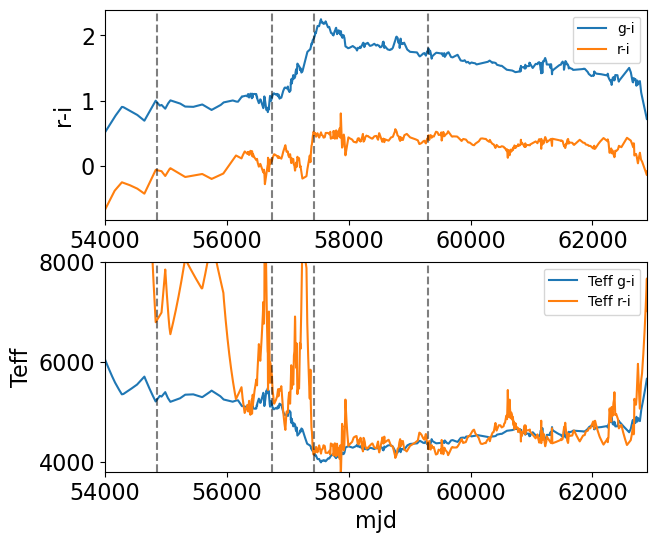

In [24]:
fig, axs = plt.subplots(2, 1, figsize=(7, 6))

ax = axs[0]

color_gi = g_new - i_new
color_ri = r_new - i_new

T_gi = vi_to_Teff( gi_to_VI(color_gi) )

T_ri = RI_to_Teff( ri_to_RI(color_ri) )

ax.plot(t_ran, color_gi, label='g-i')
ax.plot(t_ran, color_ri, label='r-i')

ax.set_ylabel('r-i')
ax.set_xlim([54000, 62900])
ax.axvline(54850, color='k', ls='--', alpha=0.5)
ax.axvline(56740, color='k', ls='--', alpha=0.5)
ax.axvline(57430, color='k', ls='--', alpha=0.5)
ax.axvline(59300, color='k', ls='--', alpha=0.5)
ax.legend()

ax = axs[1]
ax.plot(t_ran, T_gi, label='Teff g-i')
ax.plot(t_ran, T_ri, label='Teff r-i')

#plt.ylim([3900, 6000])
#plt.gca().invert_yaxis()

ax.set_ylabel('Teff')

ax.set_xlim([54000, 62900])
ax.set_ylim([3800, 8000])

ax.axvline(54850, color='k', ls='--', alpha=0.5)
ax.axvline(56740, color='k', ls='--', alpha=0.5)
ax.axvline(57430, color='k', ls='--', alpha=0.5)
ax.axvline(59300, color='k', ls='--', alpha=0.5)

ax.set_xlabel('mjd')
ax.legend()


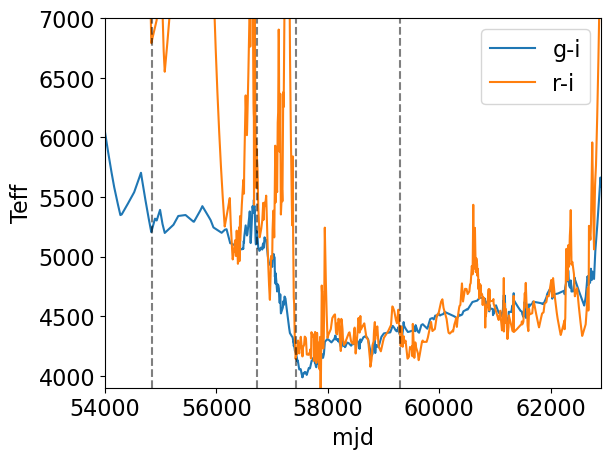

In [700]:
color_gi = g_new - i_new

color_ri = r_new - i_new

T_gi = vi_to_Teff( gi_to_VI(color_gi) )

T_ri = RI_to_Teff( ri_to_RI(color_ri) )

plt.plot(t_ran, T_gi, label='g-i')
plt.plot(t_ran, T_ri, label='r-i')

#plt.ylim([3900, 6000])
#plt.gca().invert_yaxis()

plt.ylabel('Teff')

plt.xlim([54000, 62900])
plt.ylim([3900, 7000])

plt.axvline(54850, color='k', ls='--', alpha=0.5)
plt.axvline(56740, color='k', ls='--', alpha=0.5)
plt.axvline(57430, color='k', ls='--', alpha=0.5)
plt.axvline(59300, color='k', ls='--', alpha=0.5)

plt.xlabel('mjd')
plt.legend()


## estimate radius

In [701]:
# Constants
R_sun = 6.957e10       # Solar radius in cm

T_sun = 5772           # Solar effective temperature in K
M_bol_sun = 4.74       # Solar bolometric magnitude

# Example bolometric correction function for i-band
def BC_i(T_eff):
    # assume linear and small
    bc_i = 0.1 - 0.0001 * (T_eff - 5772)
    #return bc_i
    return 0

def radius_from_Mi_Teff(M_i, T_eff):
    """
    Compute stellar radius in solar radii from i-band magnitude and effective temperature.
    
    Parameters
    ----------
    M_i : float
        Absolute magnitude in i-band
    T_eff : float
        Effective temperature in Kelvin
    
    Returns
    -------
    R : float
        Stellar radius in solar radii
    """
    BC = BC_i(T_eff)
    log_R_Rsun = (M_bol_sun - M_i - BC)/5 - 2*np.log10(T_eff/T_sun)
    R = 10**log_R_Rsun
    
    return R


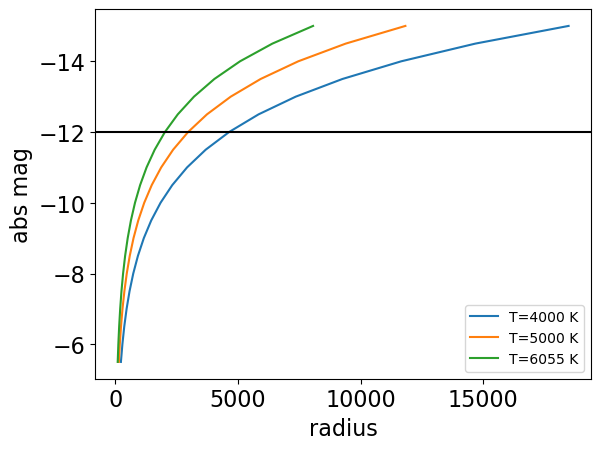

In [95]:
# radius, mag, temperature ralation

mags = np.arange(-15, -5, .5)

for ti in [4000, 5000, 6055]:
    r = radius_from_Mi_Teff(mags, ti,)

    plt.plot(r, mags, label=f'T={ti} K')

#plt.axvline(x=240, c='k')
plt.axhline(y=-12, c='k')
plt.xlabel('radius')
plt.ylabel('abs mag')
plt.gca().invert_yaxis()

plt.legend()


In [159]:
# assume initial has a 240R_sun radius
# from, Theodore R. Gull JD13 – Eta Carinae in the Context of the Most Massive Stars

abs_mag = mags[ np.argmin( np.abs(r - 240) )]

# initial magnitude
abs_mag - i_new[0]

np.float64(-29.703695376242077)

In [150]:
5 * np.log10(2300) -5 

np.float64(11.808639180087965)

In [153]:
V_new = g_new - 0.03 - 0.42*(g_new - r_new)


In [161]:
# 3rd peak 
V_new.min() + 12 # apparent 

np.float64(32.64542314939492)

In [173]:
(g_new - 32.65).min()

np.float64(-11.27852889976683)

In [702]:
color_gi = g_new - i_new

T = vi_to_Teff( gi_to_VI(color_gi) )

R_ec = radius_from_Mi_Teff(g_new - 32.65, T)


(0.0, 3200.0)

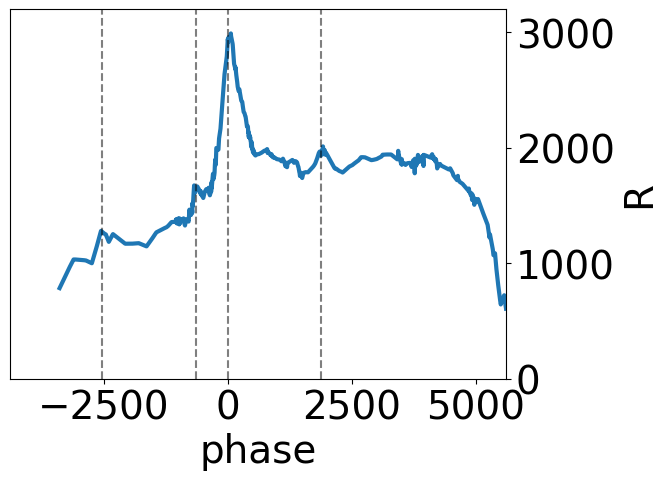

In [703]:
plt.plot(t_ran - 57388, R_ec, lw=3)

plt.axvline(54850- 57388, color='k', ls='--', alpha=0.5)
plt.axvline(56740- 57388, color='k', ls='--', alpha=0.5)
plt.axvline(57388- 57388, color='k', ls='--', alpha=0.5)
plt.axvline(59300- 57420, color='k', ls='--', alpha=0.5)

plt.xlabel('phase', fontsize=28)
plt.ylabel('R', fontsize=28)
ax = plt.gca()
ax.tick_params(axis='x', labelsize=28)  # x-axis ticks
ax.tick_params(axis='y', labelsize=28)  # y-axis ticks
plt.xlim([53000- 57388, 63000- 57388])

# Move y-axis to the right
ax.yaxis.tick_right()                  # ticks on the right
ax.yaxis.set_label_position("right")   # label on the right

plt.ylim([0, 3200])

(-4388.0, 5612.0)

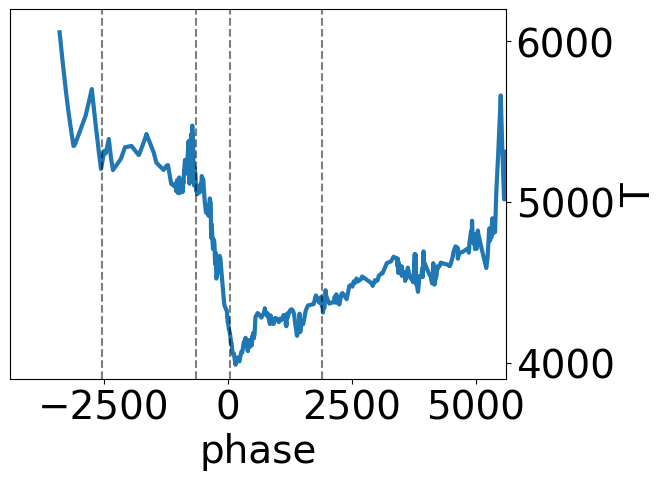

In [694]:
plt.plot(t_ran - 57388, T, lw=3)

plt.axvline(54850- 57388, color='k', ls='--', alpha=0.5)
plt.axvline(56740- 57388, color='k', ls='--', alpha=0.5)
plt.axvline(57430- 57388, color='k', ls='--', alpha=0.5)
plt.axvline(59300- 57388, color='k', ls='--', alpha=0.5)

plt.xlabel('phase', fontsize=28)
plt.ylabel('T', fontsize=28)

#plt.xlim([53000, 63000])
plt.ylim([3900, 6200])

ax = plt.gca()
# Move y-axis to the right
ax.yaxis.tick_right()                  # ticks on the right
ax.yaxis.set_label_position("right")   # label on the right

ax.tick_params(axis='x', labelsize=28)  # x-axis ticks
ax.tick_params(axis='y', labelsize=28)  # y-axis ticks
plt.xlim([53000- 57388, 63000- 57388])


In [131]:
3000 - 800

2200

In [132]:
# expanding speed

2200 * R_sun / (2*365*24*3600) /100/1000



24.266552511415526

## HR diagram

In [ ]:
T abs_mag_i

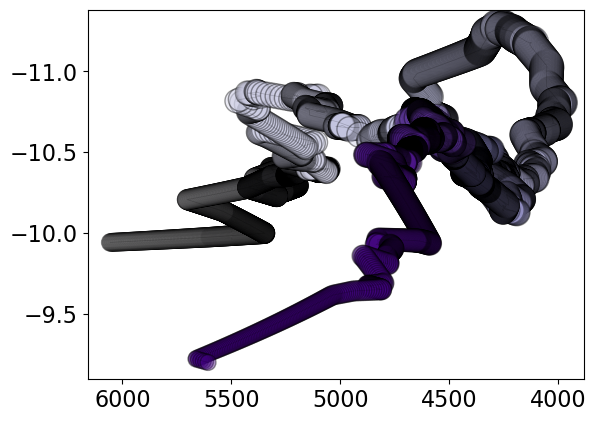

In [506]:
plt.plot(T, abs_mag_i, '-', alpha=.2, c='k', lw=.5)
plt.scatter( T, abs_mag_i , alpha=0.4, s=R_ec/5, edgecolors='black',
            c=t, cmap=plt.cm.Purples, )
plt.gca().invert_yaxis()

plt.gca().invert_xaxis()



In [494]:
R_ec.min(), R_ec.max()


(np.float64(241.7531713410676), np.float64(2989.447112150693))

In [493]:
R_ec.min()/3, R_ec.max()/3

(np.float64(80.58439044702253), np.float64(996.4823707168977))

mag vs Temperature

(-9.0, -11.6)

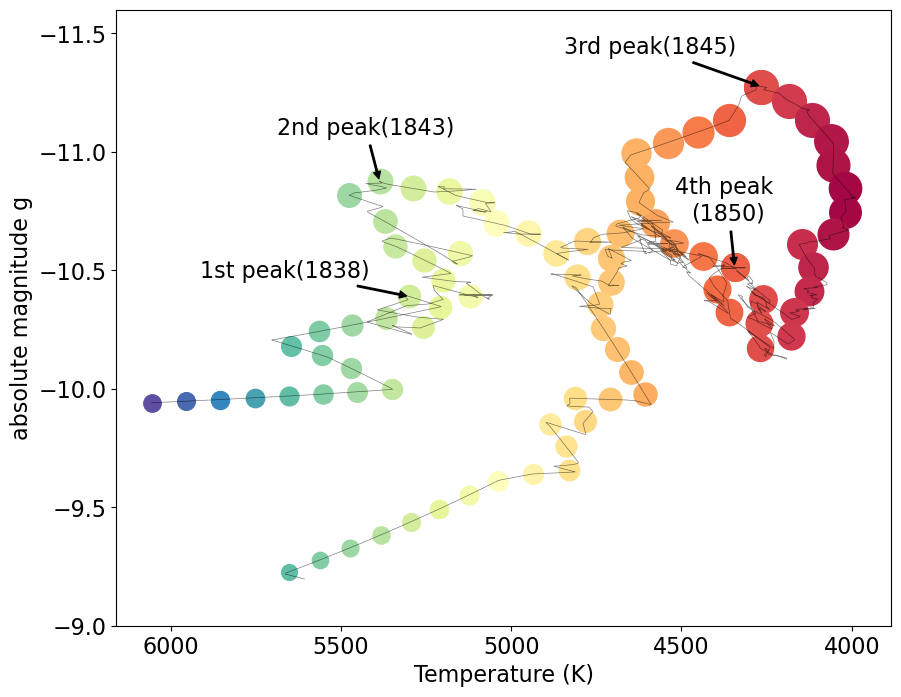

In [509]:

plt.figure(figsize=(10, 8))
idx = t_ran < 62900

step = 1

color_gi = g_new[idx][::step] - i_new[idx][::step]
mag_i = g_new[idx][::step] 
abs_mag_i = mag_i-32.65

t = t_ran[idx][::step]

T = vi_to_Teff( gi_to_VI(color_gi) )

R_ec = radius_from_Mi_Teff(abs_mag_i, T)

plt.plot(T, abs_mag_i, '-', alpha=.5, c='k', lw=.5)

#plt.scatter( T, abs_mag_i , alpha=0.4, s=R_ec/5, edgecolors='black',
#            c=t, cmap=plt.cm.Purples, )

T_show = [T[0]]
m_show = [abs_mag_i[0]]

values = np.array(t)
values = np.array(T)


# Normalize the array to range [0, 1] for the colormap
norm = (values - values.min()) / (values.max() - values.min())

# Get colors from the Purples colormap
#colors = plt.cm.Purples(0.5+0.5*norm)


colors = plt.cm.Spectral(norm)
#colors = plt.cm.RdBu(norm)

# plot the first 
plt.scatter(T[0], abs_mag_i[0], s=R_ec[0]/5, color=colors[0]);

#------------------
# plot peaks
mjd_peak1 = 54890
idx_peak1 = np.argmin(np.abs(t_ran[::step] - mjd_peak1))

x_peak1 = T[idx_peak1]
y_peak1 = abs_mag_i[idx_peak1]


#plt.text(x_peak1+600, y_peak1-0.1, '1st peak(1838)', c='k', fontsize=16)
#plt.arrow(x_peak1, y_peak1, 0, -0.1, head_width=0.05, head_length=0.05,)

plt.scatter(x_peak1, y_peak1, s=R_ec[idx_peak1]/5, color=colors[idx_peak1])

T_show.append(x_peak1)
m_show.append(y_peak1)

plt.annotate('1st peak(1838)', fontsize=16,
            xy=(x_peak1, y_peak1), xycoords='data',
            xytext=(-90, 10), textcoords='offset points',
            arrowprops=dict(facecolor='black', arrowstyle='simple, head_length=1, head_width=1', mutation_scale=5),
            horizontalalignment='center', verticalalignment='bottom')

#------------------

mjd_peak1 = 56690
idx_peak1 = np.argmin(np.abs(t_ran[::step] - mjd_peak1))
x_peak1 = T[idx_peak1]
y_peak1 = abs_mag_i[idx_peak1]
plt.scatter(x_peak1, y_peak1, s=R_ec[idx_peak1]/5, color=colors[idx_peak1])

#plt.text(x_peak1+200, y_peak1+0.2, '2nd peak(1843)', c='k', fontsize=16)
#plt.arrow(x_peak1, y_peak1, 0, 0.2)

T_show.append(x_peak1)
m_show.append(y_peak1)

plt.annotate('2nd peak(1843)', fontsize=16,
            xy=(x_peak1, y_peak1), xycoords='data',
            xytext=(-10, 30), textcoords='offset points',
            arrowprops=dict(facecolor='black', arrowstyle='simple, head_length=1, head_width=1', mutation_scale=5),
            horizontalalignment='center', verticalalignment='bottom')

#------------------------
mjd_peak1 = 57388
idx_peak1 = np.argmin(np.abs(t_ran[::step] - mjd_peak1))

x_peak1 = T[idx_peak1]
y_peak1 = abs_mag_i[idx_peak1]


plt.scatter(x_peak1, y_peak1, s=R_ec[idx_peak1]/5, color=colors[idx_peak1])

#plt.text(x_peak1, y_peak1-0.5, '3rd peak(1845)', c='k', fontsize=16)
#plt.arrow(x_peak1, y_peak1, 0, -0.5)

T_show.append(x_peak1)
m_show.append(y_peak1)

plt.annotate('3rd peak(1845)', fontsize=16,
            xy=(x_peak1, y_peak1), xycoords='data',
            xytext=(-80, 20), textcoords='offset points',
            arrowprops=dict(facecolor='black', arrowstyle='simple, head_length=1, head_width=1', mutation_scale=5),
            horizontalalignment='center', verticalalignment='bottom')

#-------------------------
mjd_peak1 = 59300
idx_peak1 = np.argmin(np.abs(t_ran[::step] - mjd_peak1))

idx_peak1 = np.argmin(np.abs(t_ran[::step] - mjd_peak1))

x_peak1 = T[idx_peak1]
y_peak1 = abs_mag_i[idx_peak1]
plt.scatter(x_peak1, y_peak1, s=R_ec[idx_peak1]/5, color=colors[idx_peak1])

#plt.text(x_peak1, y_peak1+0.2, '4th peak (1850)', c='k', fontsize=16)
#plt.arrow(x_peak1, y_peak1, 0, 0.2)

T_show.append(x_peak1)
m_show.append(y_peak1)

plt.annotate('4th peak \n(1850)', fontsize=16,
            xy=(x_peak1, y_peak1), xycoords='data',
            xytext=(-5, 30), textcoords='offset points',
            arrowprops=dict(facecolor='black', arrowstyle='simple, head_length=1, head_width=1', mutation_scale=5),
            horizontalalignment='center', verticalalignment='bottom')


# plot all, remove overlaps by distance
for color, Ti, m_i, R_i in zip(colors[1:], T[1:], abs_mag_i[1:], R_ec[1:]):
    T_show_arr = np.array(T_show)
    m_show_arr = np.array(m_show)
    dist = ((Ti - T_show_arr) / 1000 )**2 + (m_i - m_show_arr)**2
    
    if min(dist[dist>0])>.01:
        plt.scatter(Ti, m_i, s=R_i/5, color=color);
        #print('plot')
        T_show.append(Ti)
        m_show.append(m_i)

plt.gca().invert_yaxis()
plt.gca().invert_xaxis()

plt.xlabel('Temperature (K)');
plt.ylabel('absolute magnitude g')

plt.ylim([-9, -11.6])

mag vs color-gi

In [557]:
54890-62415

-7525

In [611]:
R_ec

array([784.30351538, 785.17652962, 786.0500258 , ..., 646.92629785,
       648.21802906, 649.50568716], shape=(8900,))

array([1.00000001, 1.00222746, 1.00445863, ..., 0.68036395, 0.68308365,
       0.68580018], shape=(8900,))

(0.19, 2.35)

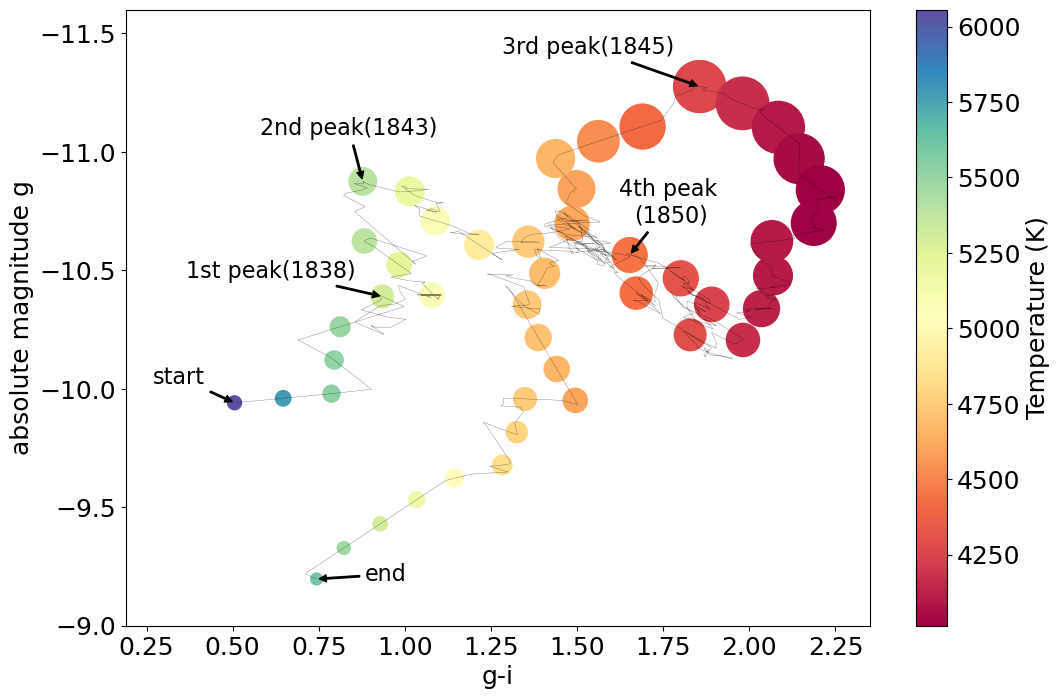

In [720]:
plt.figure(figsize=(12, 8))
idx = t_ran < 62900

step = 1

color_gi = g_new[idx][::step] - i_new[idx][::step]
mag_i = g_new[idx][::step] 
abs_mag_i = mag_i-32.65

t = t_ran[idx][::step]

T = vi_to_Teff( gi_to_VI(color_gi) )

R_ec_bk = radius_from_Mi_Teff(abs_mag_i, T)

R_ec = R_ec_bk**2 / 615.132 /2

# plot the line
plt.plot(color_gi, abs_mag_i, '-', alpha=.5, c='k', lw=.3)

#plt.scatter(color_gi, abs_mag_i, s=1, c=T, cmap=plt.cm.Spectral)


#plt.scatter( T, abs_mag_i , alpha=0.4, s=R_ec/5, edgecolors='black',
#            c=t, cmap=plt.cm.Purples, )

color_gi_show = [color_gi[0], color_gi[-1]]
m_show = [abs_mag_i[0], abs_mag_i[-1]]
T_show = [T[0], T[-1]]
R_show = [R_ec[0], R_ec[-1]]


#values = np.array(t)
values = np.array(T)

# Normalize the array to range [0, 1] for the colormap
norm = (values - values.min()) / (values.max() - values.min())

# Get colors from the Purples colormap
#colors = plt.cm.Purples(0.5+0.5*norm)

colors = plt.cm.Spectral(norm)
#colors = plt.cm.RdBu(norm)
#---------------------------------------------------
# plot the first dot

x_first = color_gi[0]
y_first = abs_mag_i[0]

#plt.scatter(x_first, y_first, s=R_ec[0]/5, color=colors[0]);

plt.annotate('start', fontsize=16,
            xy=(x_first, y_first), xycoords='data',
            xytext=(-40, 10), textcoords='offset points',
            arrowprops=dict(facecolor='black', arrowstyle='simple, head_length=1, head_width=1', mutation_scale=5),
            horizontalalignment='center', verticalalignment='bottom')

#------------------
# plot peaks
mjd_peak1 = 54890
idx_peak1 = np.argmin(np.abs(t_ran[::step] - mjd_peak1))

x_peak1 = color_gi[idx_peak1]
y_peak1 = abs_mag_i[idx_peak1]


#plt.text(x_peak1+600, y_peak1-0.1, '1st peak(1838)', c='k', fontsize=16)
#plt.arrow(x_peak1, y_peak1, 0, -0.1, head_width=0.05, head_length=0.05,)

#plt.scatter(x_peak1, y_peak1, s=R_ec[idx_peak1]/5, color=colors[idx_peak1])

color_gi_show.append(x_peak1)
m_show.append(y_peak1)
T_show.append(T[idx_peak1])
R_show.append(R_ec[idx_peak1])

plt.annotate('1st peak(1838)', fontsize=16,
            xy=(x_peak1, y_peak1), xycoords='data',
            xytext=(-80, 10), textcoords='offset points',
            arrowprops=dict(facecolor='black', arrowstyle='simple, head_length=1, head_width=1', mutation_scale=5),
            horizontalalignment='center', verticalalignment='bottom')

#---------------------

mjd_peak1 = 56690
idx_peak1 = np.argmin(np.abs(t_ran[::step] - mjd_peak1))
x_peak1 = color_gi[idx_peak1]
y_peak1 = abs_mag_i[idx_peak1]
#plt.scatter(x_peak1, y_peak1, s=R_ec[idx_peak1]/5, color=colors[idx_peak1])

#plt.text(x_peak1+200, y_peak1+0.2, '2nd peak(1843)', c='k', fontsize=16)
#plt.arrow(x_peak1, y_peak1, 0, 0.2)

color_gi_show.append(x_peak1)
m_show.append(y_peak1)
T_show.append(T[idx_peak1])
R_show.append(R_ec[idx_peak1])

plt.annotate('2nd peak(1843)', fontsize=16,
            xy=(x_peak1, y_peak1), xycoords='data',
            xytext=(-10, 30), textcoords='offset points',
            arrowprops=dict(facecolor='black', arrowstyle='simple, head_length=1, head_width=1', mutation_scale=5),
            horizontalalignment='center', verticalalignment='bottom')

#------------------

#------------------------
mjd_peak1 = 57388
idx_peak1 = np.argmin(np.abs(t_ran[::step] - mjd_peak1))

x_peak1 = color_gi[idx_peak1]
y_peak1 = abs_mag_i[idx_peak1]

#plt.scatter(x_peak1, y_peak1, s=R_ec[idx_peak1]/5, color=colors[idx_peak1])

#plt.text(x_peak1, y_peak1-0.5, '3rd peak(1845)', c='k', fontsize=16)
#plt.arrow(x_peak1, y_peak1, 0, -0.5)

color_gi_show.append(x_peak1)
m_show.append(y_peak1)
T_show.append(T[idx_peak1])
R_show.append(R_ec[idx_peak1])

plt.annotate('3rd peak(1845)', fontsize=16,
            xy=(x_peak1, y_peak1), xycoords='data',
            xytext=(-80, 20), textcoords='offset points',
            arrowprops=dict(facecolor='black', arrowstyle='simple, head_length=1, head_width=1', mutation_scale=5),
            horizontalalignment='center', verticalalignment='bottom')

#-------------------------
#mjd_peak1 = 59300
mjd_peak1 = 59360

idx_peak1 = np.argmin(np.abs(t_ran[::step] - mjd_peak1))

idx_peak1 = np.argmin(np.abs(t_ran[::step] - mjd_peak1))

x_peak1 = color_gi[idx_peak1]
y_peak1 = abs_mag_i[idx_peak1]
#plt.scatter(x_peak1, y_peak1, s=R_ec[idx_peak1]/5, color=colors[idx_peak1])

#plt.text(x_peak1, y_peak1+0.2, '4th peak (1850)', c='k', fontsize=16)
#plt.arrow(x_peak1, y_peak1, 0, 0.2)

color_gi_show.append(x_peak1)
m_show.append(y_peak1)
T_show.append(T[idx_peak1])
R_show.append(R_ec[idx_peak1])

plt.annotate('4th peak \n(1850)', fontsize=16,
            xy=(x_peak1, y_peak1), xycoords='data',
            xytext=(30, 20), textcoords='offset points',
            arrowprops=dict(facecolor='black', arrowstyle='simple, head_length=1, head_width=1', mutation_scale=5),
            horizontalalignment='center', verticalalignment='bottom')


# plot the last dot
x_last = color_gi[-1]
y_last = abs_mag_i[-1]
#plt.scatter(x_last, y_last, s=R_ec[-1]/5, color=colors[-1]);

plt.annotate('end', fontsize=16,
            xy=(x_last, y_last), xycoords='data',
            xytext=(50, -5), textcoords='offset points',
            arrowprops=dict(facecolor='black', arrowstyle='simple, head_length=1, head_width=1', mutation_scale=5),
            horizontalalignment='center', verticalalignment='bottom')


#--------------------------------------------------

# plot all, remove overlaps by distance
for color, color_gi_i, m_i, R_i, T_i in zip(colors[1:], color_gi[1:], abs_mag_i[1:], R_ec[1:], T[1:]):
    color_gi_show_arr = np.array(color_gi_show)
    m_show_arr = np.array(m_show)
    dist = ((color_gi_i - color_gi_show_arr) )**2 + (m_i - m_show_arr)**2
    
    if min(dist[dist>0])>.02:
        #sc = plt.scatter(color_gi_i, m_i, s=R_i/5, color=color);
        #print('plot')
        color_gi_show.append(color_gi_i)
        m_show.append(m_i)

        T_show.append(T_i)
        R_show.append(R_i)


color_gi_show_arr = np.array(color_gi_show)
m_show_arr = np.array(m_show)

R_show_arr = np.array(R_show)
T_show_arr = np.array(T_show)

#sc = plt.scatter(color_gi_show_arr_, m_show_arr_, s=R_show_arr/5, color=color_show);

#sc = plt.scatter(color_gi_show_arr_, m_show_arr_, s=R_show_arr/5, c=T_, cmap=plt.cm.Spectral);



sc = plt.scatter(color_gi_show_arr, m_show_arr, s=R_show_arr/5, c=T_show_arr, cmap=plt.cm.Spectral);

cbar = plt.colorbar(sc, ax=plt.gca())
#cbar.set_ticks([4000, 6000])
cbar.set_label("Temperature (K)")
#--------------------------------------------------
plt.gca().invert_yaxis()
#plt.gca().invert_xaxis()

plt.xlabel('g-i');
plt.ylabel('absolute magnitude g')

plt.ylim([-9, -11.6])

plt.xlim([0.19, 2.35])


In [631]:
len(R_show_arr)

77

In [636]:
color_gi_show_arr.shape, m_show_arr.shape

((76,), (76,))

In [632]:
color_gi_show_arr.shape, m_show_arr.shape

((76,), (76,))

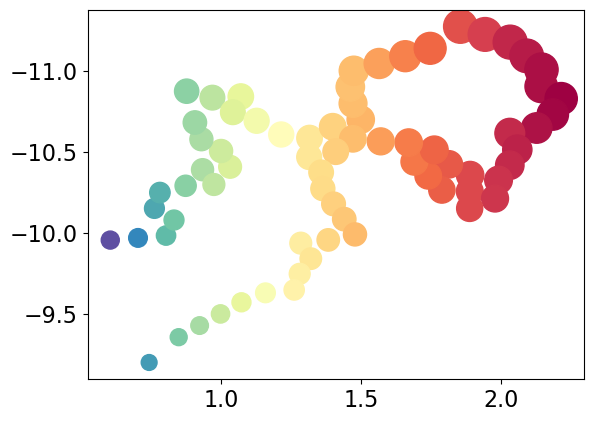

In [595]:
plt.scatter(color_gi_show_arr_, m_show_arr_, s=R_show_arr/5, c=T_, cmap=plt.cm.Spectral);
plt.gca().invert_yaxis()


In [596]:
R_show_arr.min()/5, R_show_arr.max()/5

(np.float64(129.9011374324331), np.float64(596.3297443754406))

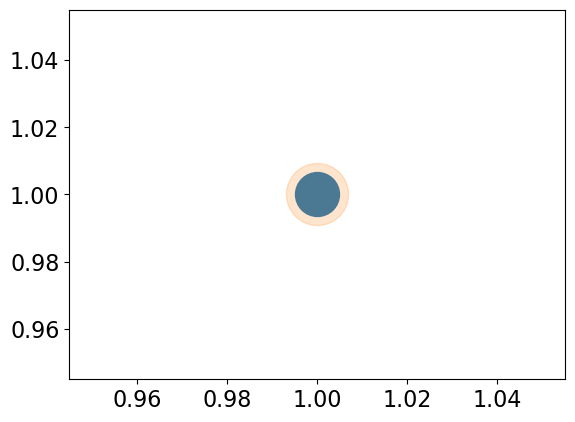

In [605]:
plt.scatter(1, 1, s=1000,)
plt.scatter(1, 1, s=2000, alpha=0.2)


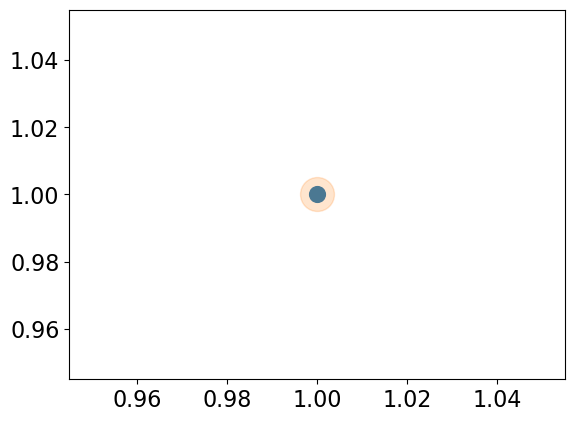

In [601]:
plt.scatter(1, 1, s=129,)
plt.scatter(1, 1, s=596, alpha=0.2)


In [597]:
596/129

4.62015503875969

In [569]:
type(R_show_arr)

numpy.ndarray

In [287]:
x_peak1

np.float64(5213.747427545189)

In [290]:
t_ran[idx_peak1]

np.int64(56700)

In [289]:
np.abs(t_ran[::step] - mjd_peak1)

array([2700, 2699, 2698, ..., 6797, 6798, 6799], shape=(9500,))

In [286]:
mjd_peak1 = 56700
idx_peak1 = np.argmin(np.abs(t_ran[::step] - mjd_peak1))
x_peak1 = T[idx_peak1]
y_peak1 = abs_mag_i[idx_peak1]


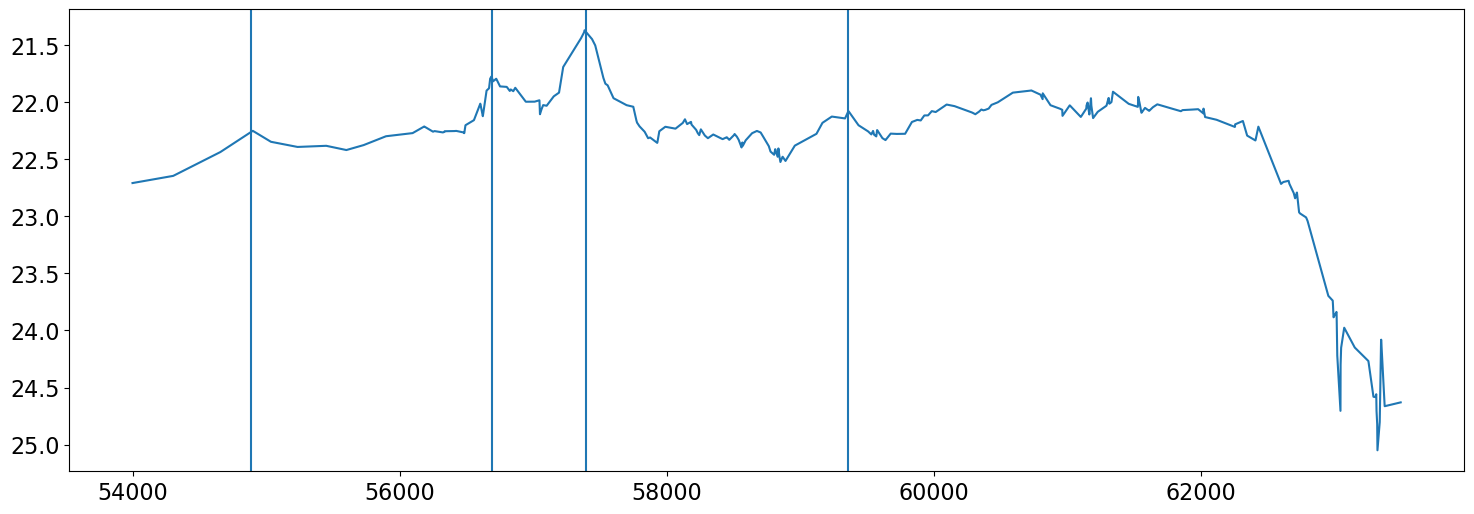

In [706]:
plt.figure(figsize=(18, 6))
plt.plot(t_ran, g_new)

plt.gca().invert_yaxis()

plt.axvline(x=54890)
plt.axvline(x=56690)
plt.axvline(x=57400)
plt.axvline(x=59360)

In [211]:
min(dist[dist>0])

np.float64(0.007522370578201858)

In [198]:
(T.max() - T.min() ) / 1000

np.float64(2.0597737800581677)

In [197]:
abs_mag_i.max() - abs_mag_i.min()

np.float64(2.03793230038551)

## compare with other transients

### load LRN and ILRT model

In [455]:
modelname = 'data/other_transients/gpmodels_for_publication/lrn_gmodel.pickle'
with open(modelname,'rb') as f:
    lrn_gmodel = pickle.load(f)

modelname = 'data/other_transients/gpmodels_for_publication/lrn_rmodel.pickle'
with open(modelname,'rb') as f:
    lrn_rmodel = pickle.load(f)

modelname = 'data/other_transients/gpmodels_for_publication/ilrt_gmodel.pickle'
with open(modelname,'rb') as f:
    ilrt_gmodel = pickle.load(f)

modelname = 'data/other_transients/gpmodels_for_publication/ilrt_rmodel.pickle'
with open(modelname,'rb') as f:
    ilrt_rmodel = pickle.load(f)


/Users/home/miniconda3/envs/sklearn-env/lib/python3.13/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator GaussianProcessRegressor from version 0.23.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Text(0.5, 1.0, 'Luminous Red Novae model')

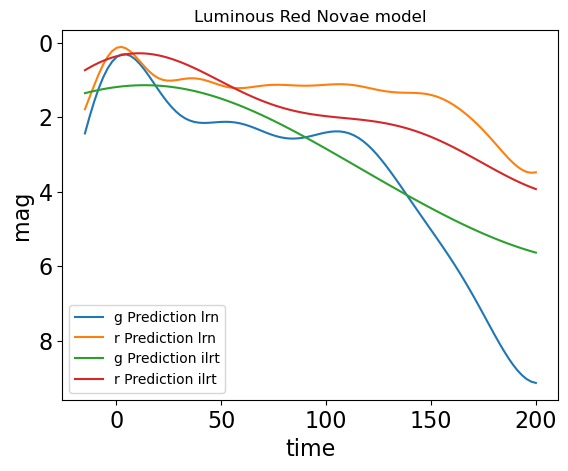

In [456]:
x = np.atleast_2d(np.linspace(-15,200,100)).T

y_pred_g_lrn, sigma_g_lrn = lrn_gmodel.predict(x, return_std=True)

y_pred_r_lrn, sigma_r_lrn = lrn_rmodel.predict(x, return_std=True)


y_pred_g_ilrt, sigma_g_ilrt = ilrt_gmodel.predict(x, return_std=True)

y_pred_r_ilrt, sigma_r_ilrt = ilrt_rmodel.predict(x, return_std=True)


plt.plot(x, y_pred_g_lrn, c=plt.cm.tab10(0), label='g Prediction lrn')
plt.plot(x, y_pred_r_lrn, c=plt.cm.tab10(1), label='r Prediction lrn')

plt.plot(x, y_pred_g_ilrt, c=plt.cm.tab10(2), label='g Prediction ilrt')
plt.plot(x, y_pred_r_ilrt, c=plt.cm.tab10(3), label='r Prediction ilrt')


plt.gca().invert_yaxis()

plt.legend()

plt.xlabel('time')
plt.ylabel('mag')

plt.title('Luminous Red Novae model')

### UGC2773 unfiltered

In [457]:
lc_ugc = pd.read_csv('./data/other_transients/UGC2773_unfiltered.csv', sep=r'\s+')

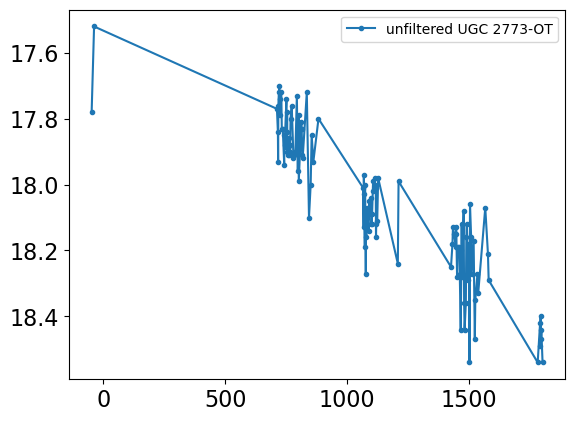

In [458]:
t_ugc = lc_ugc['MJD'].values - 55100
mag_ugc = lc_ugc['mag'].values

plt.plot(t_ugc, mag_ugc, '.-', label='unfiltered UGC 2773-OT')

plt.gca().invert_yaxis()
plt.legend()

(-1000.0, 2000.0)

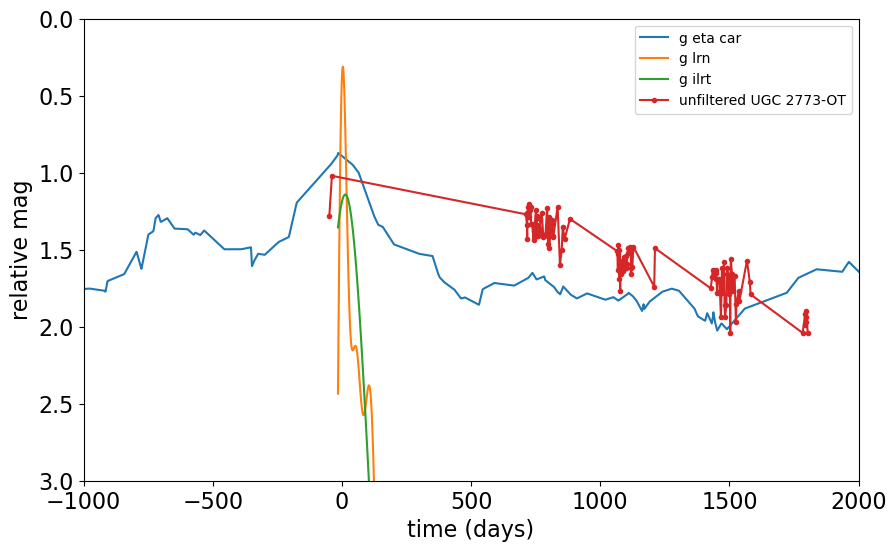

In [483]:
plt.figure(figsize=(10, 6))

plt.plot(t_ran-57400, g_new-20.5, label='g eta car')

plt.plot(x, y_pred_g_lrn, label='g lrn')

plt.plot(x, y_pred_g_ilrt, label='g ilrt')

plt.plot(t_ugc, mag_ugc-16.5, '.-', label='unfiltered UGC 2773-OT')

plt.ylim([0, 3])
plt.gca().invert_yaxis()

plt.xlabel('time (days)')
plt.ylabel('relative mag')
plt.legend()

plt.xlim([-1000, 2000])



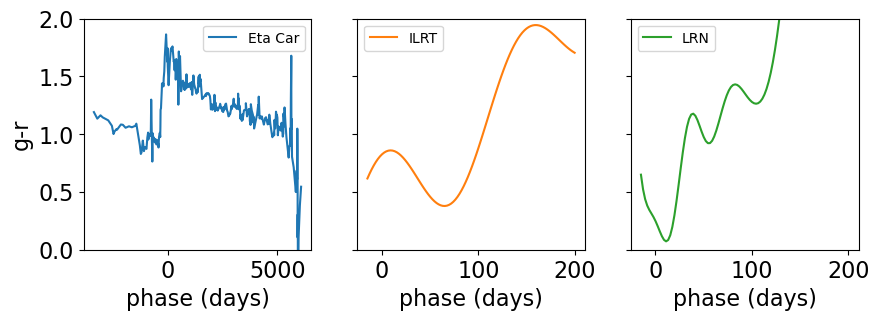

In [460]:
fig, axs = plt.subplots(1, 3, figsize=(10, 3), sharey=True)

ax = axs[0]
ax.plot(t_ran-57400, g_new-r_new, label='Eta Car', c=plt.matplotlib.cm.tab10(0))
ax.set_ylim([0, 2])
ax.set_ylabel('g-r')
ax.set_xlabel('phase (days)')
ax.legend()

ax = axs[1]
ax.plot(x, y_pred_g_ilrt-y_pred_r_ilrt, label='ILRT', c=plt.matplotlib.cm.tab10(1))
ax.set_xlabel('phase (days)')
ax.legend()


ax = axs[2]
ax.plot(x, y_pred_g_lrn-y_pred_r_lrn, label='LRN', c=plt.matplotlib.cm.tab10(2))
ax.set_xlabel('phase (days)')
ax.legend()



(-3000.0, 4000.0)

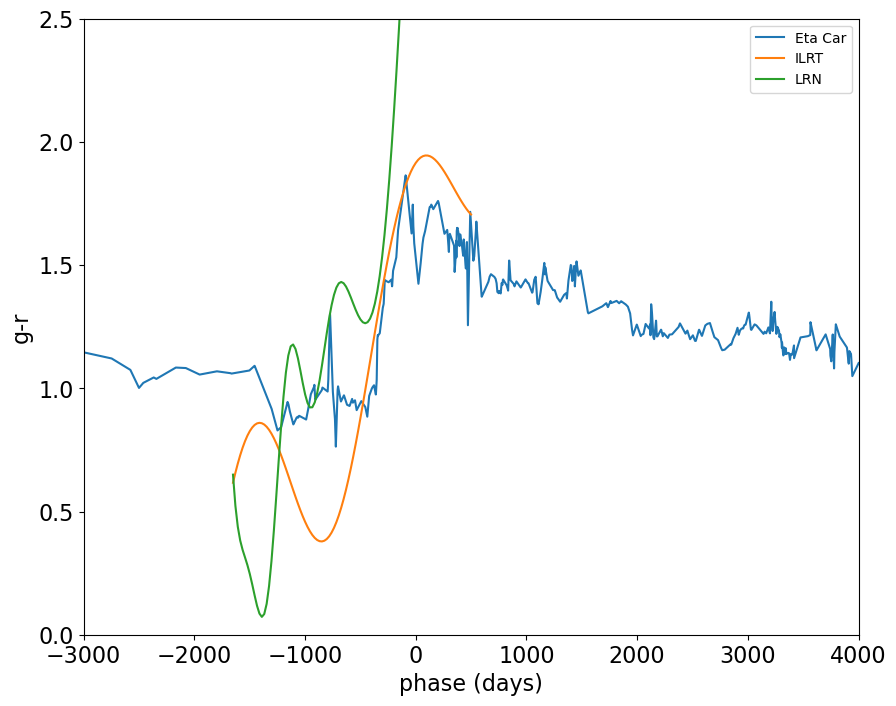

In [481]:
fig, axs = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

ax = axs
ax.plot(t_ran-57400, g_new-r_new, label='Eta Car', c=plt.matplotlib.cm.tab10(0))
ax.set_ylim([0, 2])
ax.set_ylabel('g-r')
ax.set_xlabel('phase (days)')
ax.legend()

#ax = axs[1]
ax.plot((x-150)*10, y_pred_g_ilrt-y_pred_r_ilrt, label='ILRT', c=plt.matplotlib.cm.tab10(1))
ax.set_xlabel('phase (days)')
ax.legend()


#ax = axs[2]
ax.plot((x-150)*10, y_pred_g_lrn-y_pred_r_lrn, label='LRN', c=plt.matplotlib.cm.tab10(2))
ax.set_xlabel('phase (days)')
ax.legend()

plt.ylim([0, 2.5])

plt.xlim([-3000, 4000])

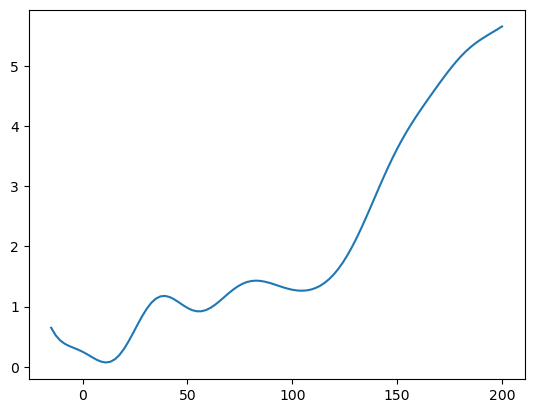

In [415]:
plt.plot(x, y_pred_g_lrn-y_pred_r_lrn,label='g ilrt')


## period analysis

In [198]:

t_ran = np.arange(54000, 63500)

g_flux_new = splev(t_ran, splrep(LCm2_g.loc[working_inds_g,'mjd'], LCm2_g.loc[working_inds_g,'mJyas2'], k=1))




Text(0, 0.5, 'flux')

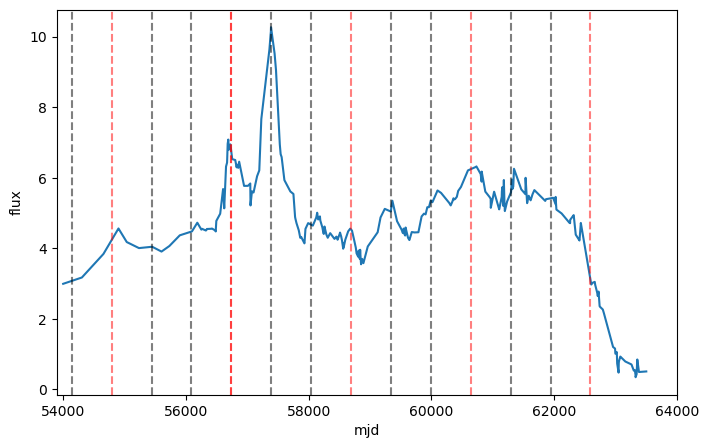

In [253]:
plt.figure(figsize=(8, 5))

plt.plot(t_ran, g_flux_new)

peak1 = 54850
peak2 = 56740
peak3 = 57430
peak4 = 59300

#axs.axvline(peak1, color='k', ls='--', alpha=0.5)
#axs.axvline(peak2, color='k', ls='--', alpha=0.5)
#axs.axvline(peak3, color='k', ls='--', alpha=0.5)
#axs.axvline(peak4, color='k', ls='--', alpha=0.5)

ax = plt.gca()
#-------
for i in range(10):
    c = 'r' if i%3==0 else 'k'
    ax.axvline(peak2 + 650*i, color=c, ls='--', alpha=0.5)
    ax.axvline(peak2 - 650*i, color=c, ls='--', alpha=0.5)


plt.xlim([53900, 64000])

plt.xlabel('mjd')

plt.ylabel('flux')

In [241]:

T_ = t_ran[t_ran<62000]
g_ = g_flux_new[t_ran<62000]

Duration = T_.max() - T_.min()

Nsample = len(T_)

Sample_rate = Nsample / Duration

In [242]:
Fourier = np.fft.fft( g_)

Freq = np.fft.fftfreq(Nsample, 1/Sample_rate)

In [243]:
Fourier_mag = np.abs(Fourier)


/var/folders/yb/hm0wbr8128v_fbvy474l5s6m0000gn/T/ipykernel_9884/242569242.py:1: RuntimeWarning: divide by zero encountered in divide
  periods = 1/Freq/365


(0.0, 2500.0)

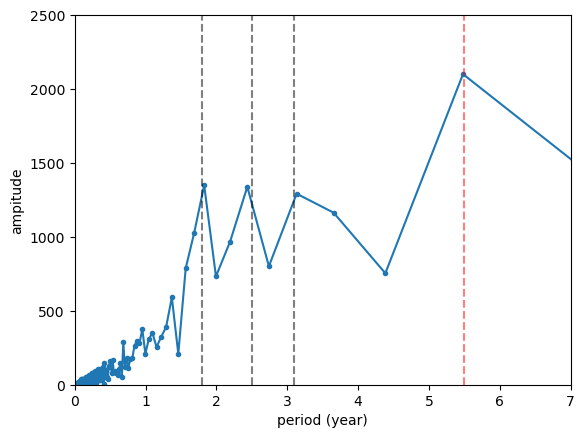

In [424]:

periods = 1/Freq/365
plt.plot(periods, Fourier_mag, '.-')

plt.xlim(0, 25)

plt.axvline(1.8, c='k', ls='--', alpha=0.5)
plt.axvline(2.5, c='k', ls='--', alpha=0.5)
plt.axvline(3.1, c='k', ls='--', alpha=0.5)

plt.axvline(5.5, c='r', ls='--', alpha=0.5)
#plt.axvline(11, )

plt.xlabel('period (year)')

plt.ylabel('ampitude')

plt.xlim([0, 7])
plt.ylim([0, 2500])

In [275]:
Fourier_new = Fourier.copy()
#Fourier_new[Fourier_mag<1000] = 0


#Fourier_new[Fourier_mag<1200] = 0
Fourier_new[(np.abs(periods)<1.5) | (np.abs(periods)>25)] = 0


iFourier = np.fft.ifft(Fourier_new)

Fourier_new_mag = np.abs(Fourier_new)


/var/folders/yb/hm0wbr8128v_fbvy474l5s6m0000gn/T/ipykernel_9884/131401637.py:1: RuntimeWarning: divide by zero encountered in divide
  plt.plot(1/Freq/365, Fourier_mag, '.-')
/var/folders/yb/hm0wbr8128v_fbvy474l5s6m0000gn/T/ipykernel_9884/131401637.py:3: RuntimeWarning: divide by zero encountered in divide
  plt.plot(1/Freq/365, Fourier_new_mag, '.-')


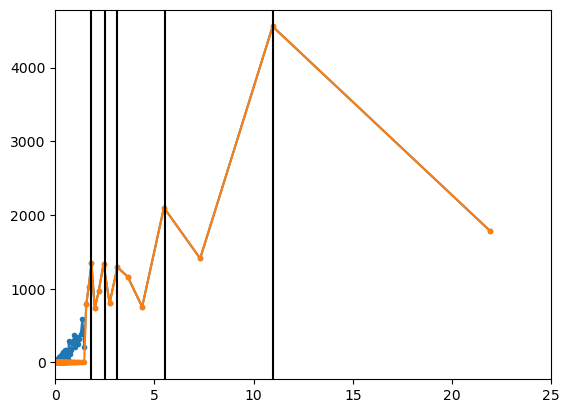

In [276]:
plt.plot(1/Freq/365, Fourier_mag, '.-')

plt.plot(1/Freq/365, Fourier_new_mag, '.-')

plt.xlim(0, 25)

plt.axvline(1.8, c='k')
plt.axvline(2.5, c='k')
plt.axvline(3.1, c='k')

plt.axvline(5.54, c='k')
plt.axvline(11, c='k')



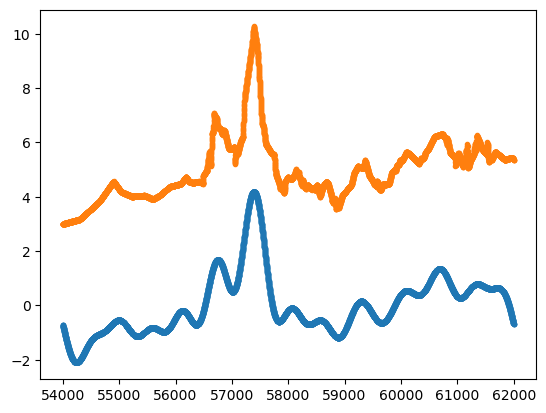

In [277]:
plt.plot(T_, iFourier, '.')
plt.plot(T_, g_, '.')

### plot image

In [424]:
eta_car_2mass = plt.imread('figures/eta_car_2mass.png', )

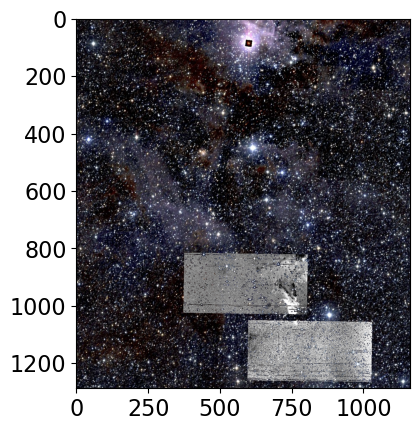

In [432]:
plt.imshow(eta_car_2mass[:,:,:4])

plt.axvline()




In [433]:
eta_car_2mass.shape

(1288, 1164, 4)